Chemin DB : c:\Users\fresm\Pictures\Data project\customer-data-pipeline-ecommerce\data\ecommerce.db
Base trouvée ? True

Dataframe chargé : 3,588 lignes × 17 colonnes
Type actuel de order_date : str

🔧 Conversion de order_date...
Type final de order_date : datetime64[us]

📊 KPI GLOBAUX
💰 Chiffre d'Affaires Total      : $4,924,090.00
📦 Nombre total de commandes     : 3,588
👥 Clients uniques               : 292
📈 Panier Moyen (AOV)            : $1,372.38
📦 Quantité moyenne              : 3.01
🚚 Taux de retour                : 30.5%
📅 Période analysée              : du 2023-01-01 au 2024-01-03

📈 Création des graphiques...


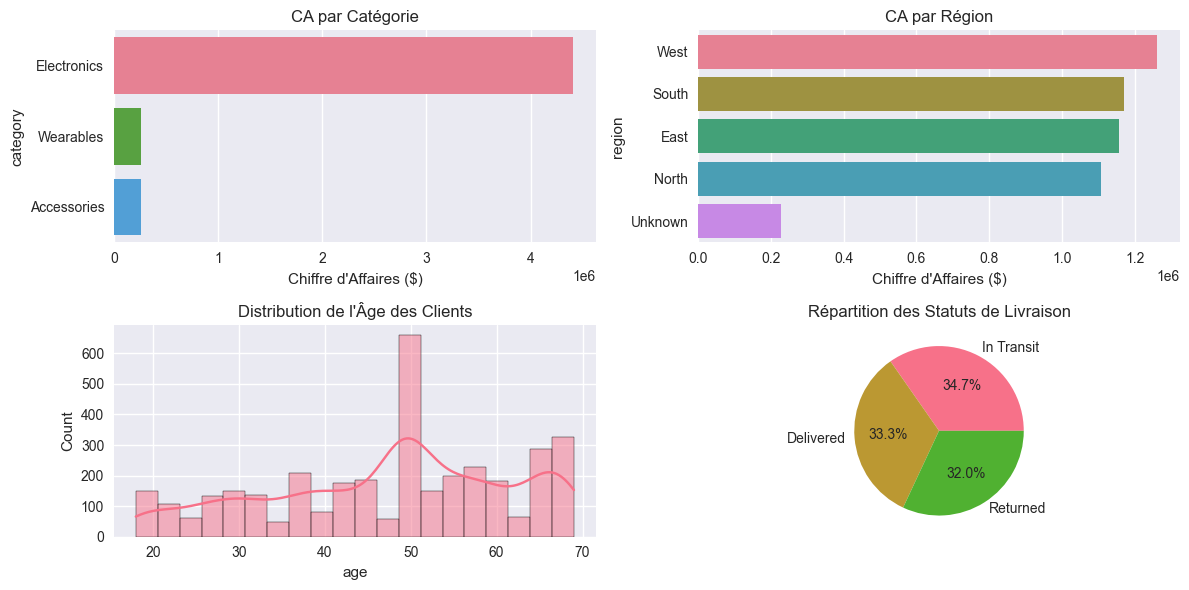

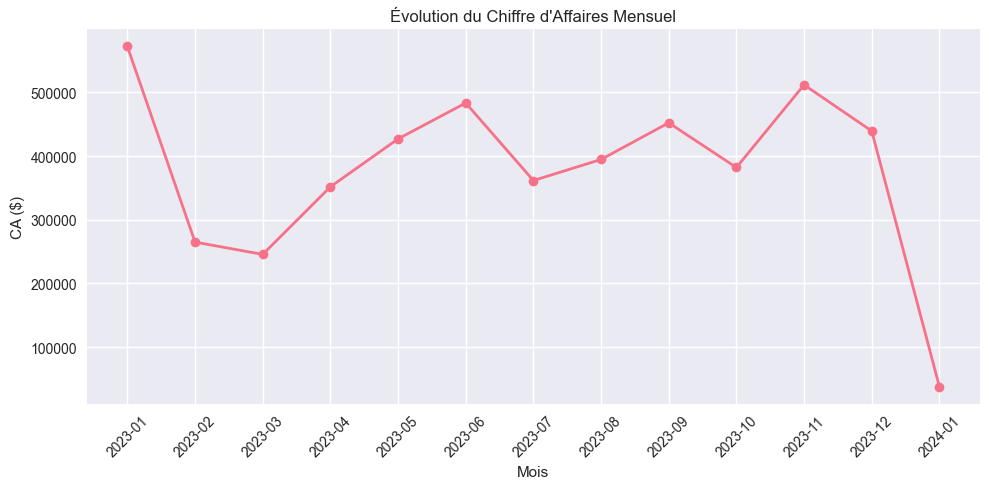


🔍 Calcul RFM...
✅ RFM calculé sur 292 clients

🏆 Top 10 clients par valeur monétaire :


,customer_id,monetary,frequency,recency
93,CUST0095,157080,63,15
197,CUST0204,145500,45,75
127,CUST0131,127080,48,47
272,CUST0281,107100,48,37
134,CUST0139,91750,35,3
139,CUST0144,86600,25,33
154,CUST0160,82500,36,49
30,CUST0031,64000,35,20
196,CUST0203,62400,25,90
169,CUST0176,62000,25,48



🎉 Analyse Exploratoire terminée !


In [2]:
# ===================== 02 - EDA E-COMMERCE (Version sans Plotly) =====================
# Customer Data Pipeline & Analytics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
import warnings

warnings.filterwarnings('ignore')

# ===================== CHEMINS =====================
BASE_PATH = os.path.dirname(os.getcwd())   
DB_PATH = os.path.join(BASE_PATH, 'data', 'ecommerce.db')

print(f"Chemin DB : {DB_PATH}")
print(f"Base trouvée ? {os.path.exists(DB_PATH)}\n")

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Configuration visuelle
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# ===================== CHARGEMENT =====================
conn = sqlite3.connect(DB_PATH)

dim_customers = pd.read_sql_query("SELECT * FROM dim_customers", conn)
dim_products = pd.read_sql_query("SELECT * FROM dim_products", conn)
fact_orders = pd.read_sql_query("SELECT * FROM fact_orders", conn)

conn.close()

df = (fact_orders
      .merge(dim_customers, on='customer_key', how='left')
      .merge(dim_products, on='product_key', how='left'))

print(f"Dataframe chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Type actuel de order_date : {df['order_date'].dtype}")

# ===================== CONVERSION FORCÉE DE LA DATE =====================
print("\n🔧 Conversion de order_date...")

df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

if not pd.api.types.is_datetime64_any_dtype(df['order_date']):
    df['order_date'] = pd.to_datetime(df['order_date'].astype(str).str[:10], errors='coerce')

# Remplacement des dates manquantes
if df['order_date'].isna().any():
    median_date = df['order_date'].median()
    df['order_date'] = df['order_date'].fillna(median_date)
    print(f"→ Dates manquantes remplacées par la médiane")

print(f"Type final de order_date : {df['order_date'].dtype}")

# ===================== KPI GLOBAUX =====================
total_revenue = df['total_price'].sum()
total_orders = len(df)
unique_customers = df['customer_id'].nunique()
avg_order_value = total_revenue / total_orders if total_orders > 0 else 0
avg_quantity = df['quantity'].mean()

return_rate = (df['shipping_status'].str.lower() == 'returned').mean() * 100

date_min = df['order_date'].min().date()
date_max = df['order_date'].max().date()

print("\n" + "="*75)
print("📊 KPI GLOBAUX")
print("="*75)
print(f"💰 Chiffre d'Affaires Total      : ${total_revenue:,.2f}")
print(f"📦 Nombre total de commandes     : {total_orders:,}")
print(f"👥 Clients uniques               : {unique_customers:,}")
print(f"📈 Panier Moyen (AOV)            : ${avg_order_value:,.2f}")
print(f"📦 Quantité moyenne              : {avg_quantity:.2f}")
print(f"🚚 Taux de retour                : {return_rate:.1f}%")
print(f"📅 Période analysée              : du {date_min} au {date_max}")
print("="*75)

# ===================== VISUALISATIONS (avec Matplotlib + Seaborn) =====================
print("\n📈 Création des graphiques...")

plt.figure(figsize=(12, 6))

# 1. CA par Catégorie
plt.subplot(2, 2, 1)
cat_revenue = df.groupby('category')['total_price'].sum().sort_values(ascending=False)
sns.barplot(x=cat_revenue.values, y=cat_revenue.index, palette="husl")
plt.title("CA par Catégorie")
plt.xlabel("Chiffre d'Affaires ($)")

# 2. CA par Région
plt.subplot(2, 2, 2)
region_revenue = df.groupby('region')['total_price'].sum().sort_values(ascending=False)
sns.barplot(x=region_revenue.values, y=region_revenue.index, palette="husl")
plt.title("CA par Région")
plt.xlabel("Chiffre d'Affaires ($)")

# 3. Distribution de l'âge
plt.subplot(2, 2, 3)
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Distribution de l'Âge des Clients")

# 4. Statuts de livraison
plt.subplot(2, 2, 4)
df['shipping_status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Répartition des Statuts de Livraison")
plt.ylabel("")

plt.tight_layout()
plt.show()

# Évolution mensuelle
df['month_year'] = df['order_date'].dt.to_period('M').astype(str)
monthly = df.groupby('month_year')['total_price'].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(monthly['month_year'], monthly['total_price'], marker='o', linewidth=2)
plt.title("Évolution du Chiffre d'Affaires Mensuel")
plt.xlabel("Mois")
plt.ylabel("CA ($)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# ===================== RFM =====================
print("\n🔍 Calcul RFM...")

rfm = df.groupby('customer_id').agg({
    'order_date': ['max', 'count'],
    'total_price': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'last_order', 'frequency', 'monetary']
rfm['recency'] = (df['order_date'].max() - rfm['last_order']).dt.days

rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1], duplicates='drop')
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5], duplicates='drop')
rfm['m_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5], duplicates='drop')

print(f"✅ RFM calculé sur {len(rfm)} clients")

print("\n🏆 Top 10 clients par valeur monétaire :")
display(rfm.nlargest(10, 'monetary')[['customer_id', 'monetary', 'frequency', 'recency']])

print("\n🎉 Analyse Exploratoire terminée !")